# Task 1:

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
    image (numpy array): Original image.
    factor (int): Factor by which to downsample.
    Returns:
    numpy array: Downsampled image.
    """
    height, width = image.shape[:2]

    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)

    return sampled_image

def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
    image (numpy array): Original image.
    levels (int): Number of grayscale levels.
    Returns:
    numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)

    return quantized_image

def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
    original (numpy array): Original image.
    sampled (numpy array): Sampled image.
    quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()

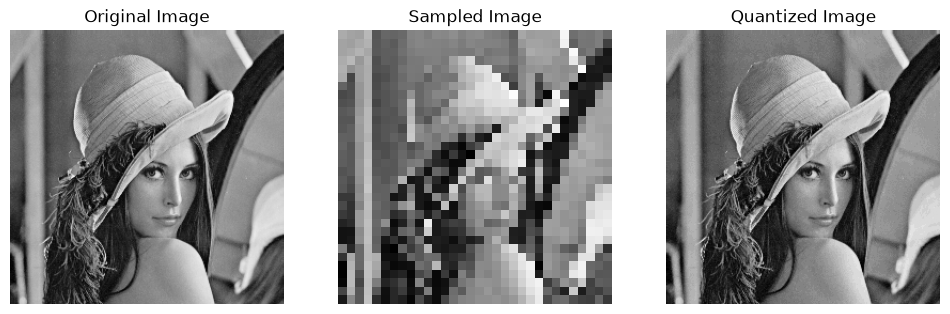

In [25]:
image_path='../images/lena_gray_256.tif'
sampling_factor=8
quantization_levels=32

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image,
quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

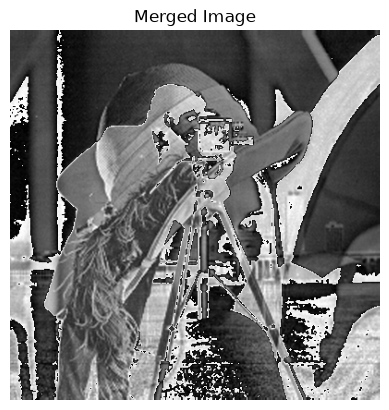

In [ ]:
from PIL import Image

img1=Image.open('../images/lena_gray_256.tif')
img2=Image.open ('../images/cameraman.tif')
resize=(400,400)
img1=img1.resize(resize,Image.Resampling.LANCZOS)
img2=img2.resize(resize,Image.Resampling.LANCZOS)
im1arr=np.asarray(img1)
im2arr=np.asarray(img2)

addition=im1arr+im2arr

plt.imshow(addition, cmap='gray')
plt.title('Merged Image')
plt.axis('off')
plt.show()

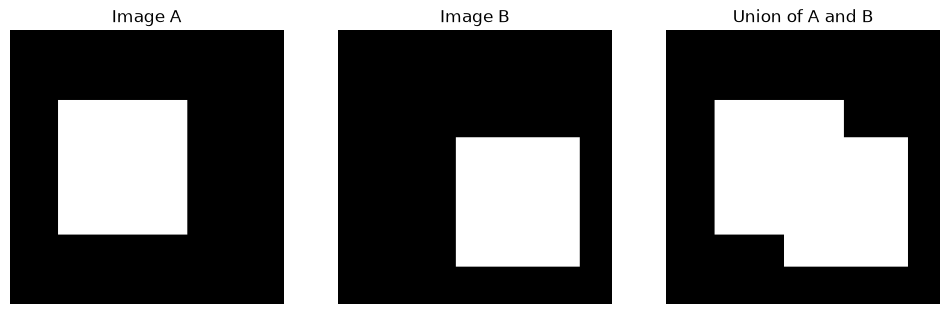

In [ ]:
img3=Image.open('../images/A.png')
img4=Image.open('../images/B.png')

resize=(400,400)
img3=img3.resize(resize,Image.Resampling.LANCZOS)
img4=img4.resize(resize,Image.Resampling.LANCZOS)

im3arr=np.asarray(img3)
im4arr=np.asarray(img4)

union=im4arr|im3arr
resultImage2=Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img3, cmap='gray')
plt.title('Image A')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(img4, cmap='gray')
plt.title('Image B')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(resultImage2, cmap='gray')
plt.title('Union of A and B')
plt.axis('off')
plt.show()


# Task 2:

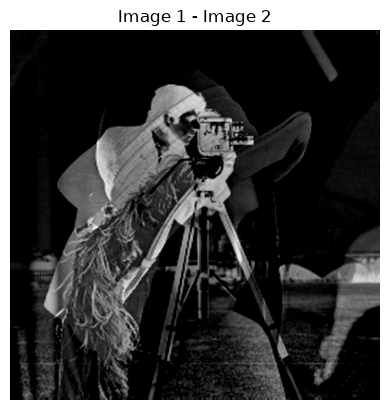

In [41]:
subtraction = cv2.subtract(im1arr, im2arr)

plt.imshow(subtraction, cmap="gray")
plt.title("Image 1 - Image 2")
plt.axis("off")
plt.show()

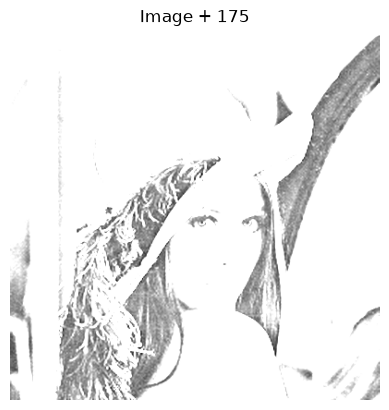

In [37]:
added_constant = cv2.add(im1arr, 175)

plt.imshow(added_constant, cmap="gray")
plt.title("Image + 175")
plt.axis("off")
plt.show()

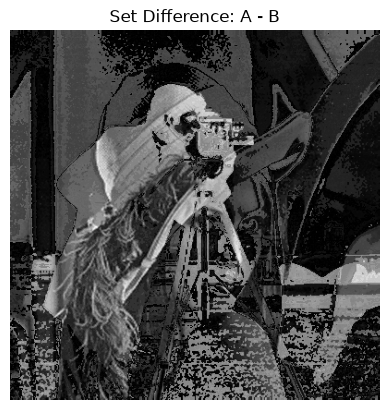

In [42]:
difference = im1arr & (~im2arr)

plt.imshow(difference, cmap="gray")
plt.title("Set Difference: A - B")
plt.axis("off")
plt.show()

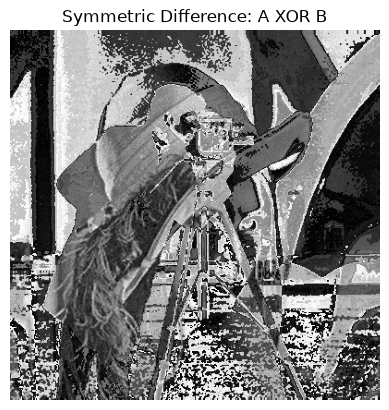

In [46]:
symmetric_difference = im1arr ^ im2arr

plt.imshow(symmetric_difference, cmap="gray")
plt.title("Symmetric Difference: A XOR B")
plt.axis("off")
plt.show()

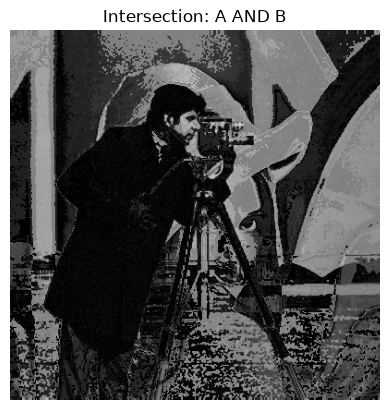

In [47]:
intersection = im1arr & im2arr

plt.imshow(intersection, cmap="gray", vmin=0, vmax=255)
plt.title("Intersection: A AND B")
plt.axis("off")
plt.show()

# Task 2 Combined:

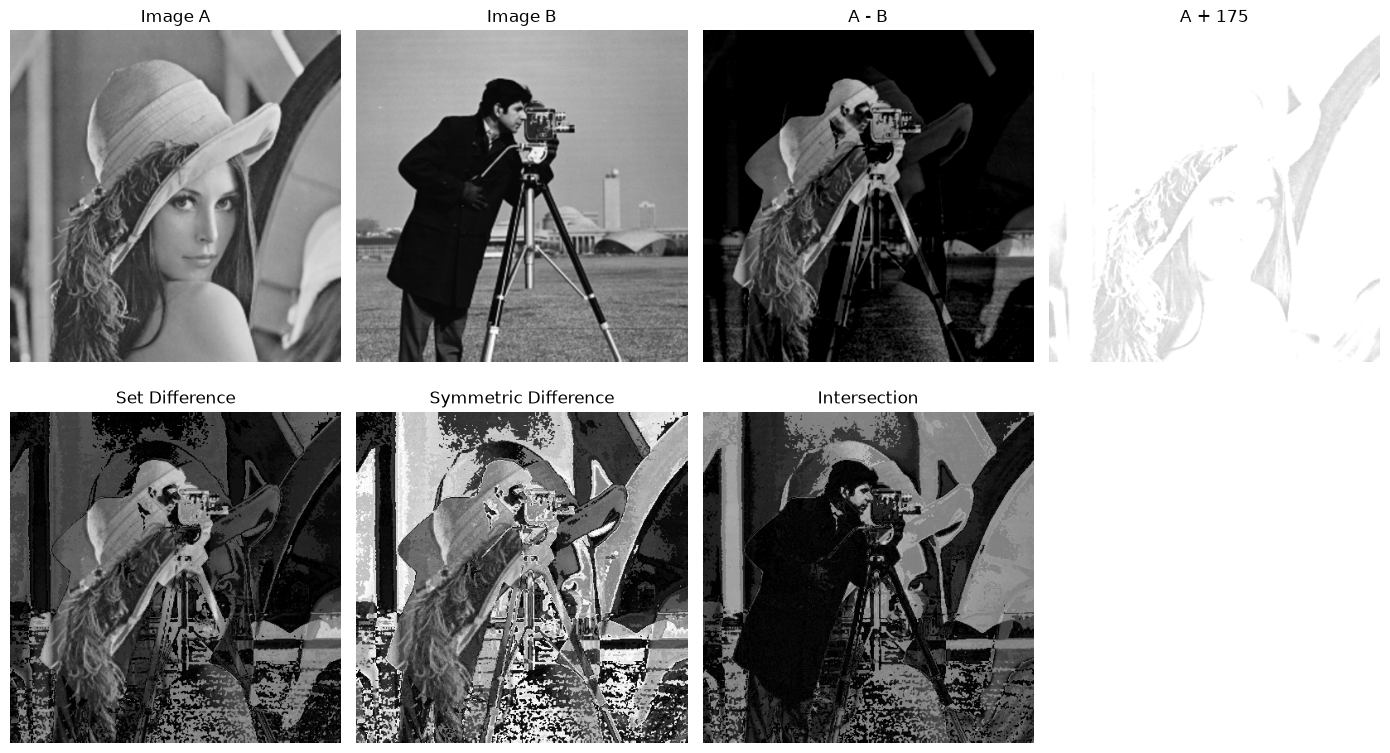

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale images
img1 = cv2.imread("../images/lena_gray_256.tif", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("../images/cameraman.tif", cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise FileNotFoundError("Unable to load one or both images.")

# Resize to same dimensions
img1 = cv2.resize(img1, (400, 400))
img2 = cv2.resize(img2, (400, 400))

# 1. Subtraction
subtraction = cv2.subtract(img1, img2)

# 2. Add constant 175
added_constant = cv2.add(img1, 175)

# 3. Set difference: A ∩ B'
set_difference = cv2.bitwise_and(
    img1,
    cv2.bitwise_not(img2)
)

# 4. Symmetric difference: A XOR B
symmetric_difference = cv2.bitwise_xor(img1, img2)

# 5. Intersection: A AND B
intersection = cv2.bitwise_and(img1, img2)


# Display results
images = [
    img1,
    img2,
    subtraction,
    added_constant,
    set_difference,
    symmetric_difference,
    intersection
]

titles = [
    "Image A",
    "Image B",
    "A - B",
    "A + 175",
    "Set Difference",
    "Symmetric Difference",
    "Intersection"
]

plt.figure(figsize=(14, 8))

for i, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()